# Customer Churn Prediction

## Phase 4: Baseline Machine Learning Models

### Objective

The objective of this phase is to train and evaluate traditional machine-learning models as baseline models for customer churn prediction.

### Models

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df = df.drop("customerID", axis=1)

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [5]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [7]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [10]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [13]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [14]:
y_pred_lr = logistic_model.predict(X_test)

In [15]:
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [16]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

In [17]:
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_roc_auc)

Logistic Regression Results
---------------------------
Accuracy : 0.8055358410220014
Precision: 0.6582278481012658
Recall   : 0.5561497326203209
F1 Score : 0.6028985507246376
ROC-AUC  : 0.8420134852359917


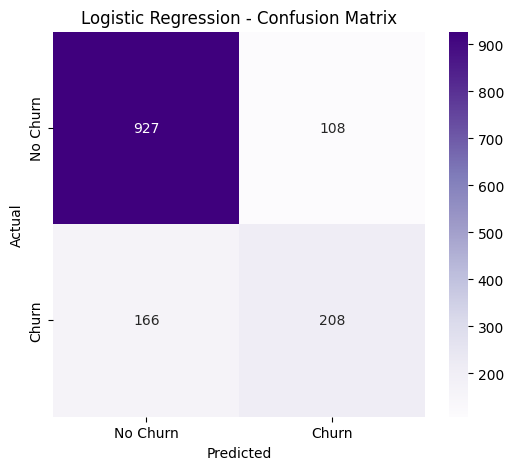

In [18]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [20]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [21]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [22]:
y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [23]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Decision Tree Results
---------------------
Accuracy : 0.794180269694819
Precision: 0.6296296296296297
Recall   : 0.5454545454545454
F1 Score : 0.5845272206303724
ROC-AUC  : 0.8283577462605594


In [24]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [25]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [26]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [27]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Accuracy : 0.7892122072391767
Precision: 0.6305084745762712
Recall   : 0.49732620320855614
F1 Score : 0.5560538116591929
ROC-AUC  : 0.8225800201503525


In [28]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)


In [29]:
xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [30]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [31]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("---------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)


XGBoost Results
---------------
Accuracy : 0.8019872249822569
Precision: 0.6567656765676567
Recall   : 0.5320855614973262
F1 Score : 0.587887740029542
ROC-AUC  : 0.8444922369474799


In [32]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})


In [33]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.658228,0.556150,0.602899,0.842013
1,Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358
2,Random Forest,0.789212,0.630508,0.497326,0.556054,0.822580
3,XGBoost,0.801987,0.656766,0.532086,0.587888,0.844492


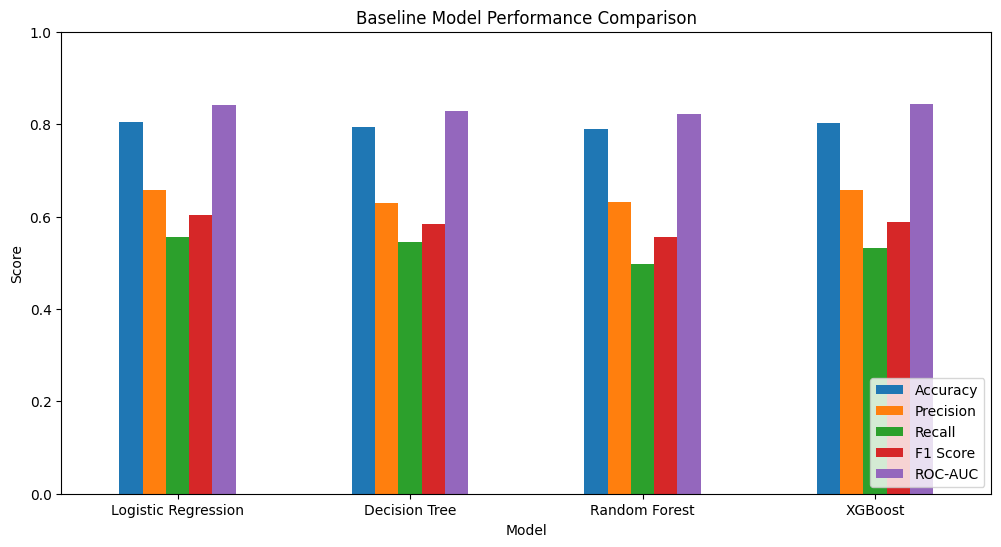

In [34]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.ylim(0, 1)

plt.legend(loc="lower right")

plt.show()

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)


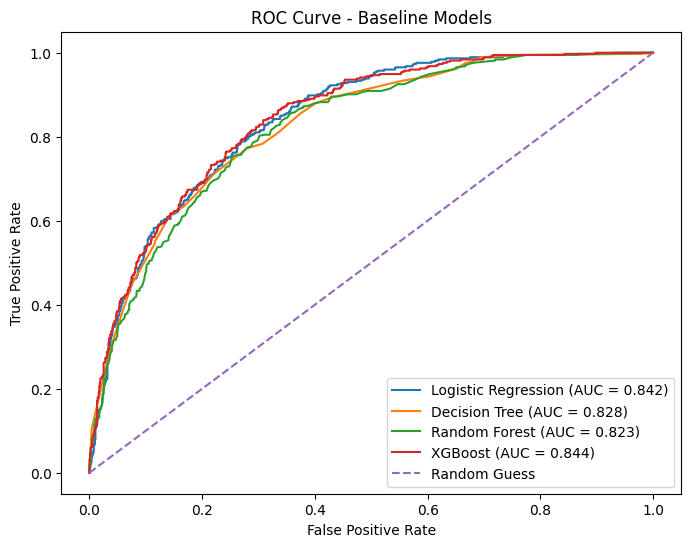

In [36]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Baseline Models")

plt.legend()

plt.show()


In [37]:
best_accuracy_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_roc_auc_model = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

best_f1_model = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Baseline Model Interpretation")
print("-----------------------------")
print("Highest Accuracy:", best_accuracy_model)
print("Highest ROC-AUC :", best_roc_auc_model)
print("Best F1 Score   :", best_f1_model)
print(
    "Final model selection should be based on the complete evaluation, "
    "not accuracy alone."
)


Baseline Model Interpretation
-----------------------------
Highest Accuracy: Logistic Regression
Highest ROC-AUC : XGBoost
Best F1 Score   : Logistic Regression
Final model selection should be based on the complete evaluation, not accuracy alone.


In [38]:
reports_dir = os.path.join("..", "reports")

os.makedirs(reports_dir, exist_ok=True)

baseline_results_path = os.path.join(
    reports_dir,
    "baseline_model_comparison.csv"
)

results.to_csv(
    baseline_results_path,
    index=False
)

print("Saved baseline model comparison to:", baseline_results_path)


Saved baseline model comparison to: ..\reports\baseline_model_comparison.csv
